In [22]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [23]:
import numpy as np
import matplotlib.pyplot as plt

In [24]:
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def sigmoid_derivative(x):
    return x * (1 - x)

In [25]:
X = np.array([[0,0],
              [0,1],
              [1,0],
              [1,1]])

y = np.array([[0],
              [1],
              [1],
              [0]])


In [26]:
np.random.seed(1)

input_neurons = 2
hidden_neurons = 2
output_neurons = 1

W1 = np.random.rand(input_neurons, hidden_neurons)
b1 = np.zeros((1, hidden_neurons))

W2 = np.random.rand(hidden_neurons, output_neurons)
b2 = np.zeros((1, output_neurons))

learning_rate = 0.1
epochs = 10000
losses = []


In [27]:
for _ in range(epochs):

    z1 = np.dot(X, W1) + b1
    a1 = sigmoid(z1)

    z2 = np.dot(a1, W2) + b2
    y_hat = sigmoid(z2)

    loss = np.mean((y - y_hat) ** 2)
    losses.append(loss)

    error_output = y - y_hat
    delta_output = error_output * sigmoid_derivative(y_hat)

    error_hidden = delta_output.dot(W2.T)
    delta_hidden = error_hidden * sigmoid_derivative(a1)

    W2 += a1.T.dot(delta_output) * learning_rate
    b2 += np.sum(delta_output, axis=0, keepdims=True) * learning_rate

    W1 += X.T.dot(delta_hidden) * learning_rate
    b1 += np.sum(delta_hidden, axis=0, keepdims=True) * learning_rate


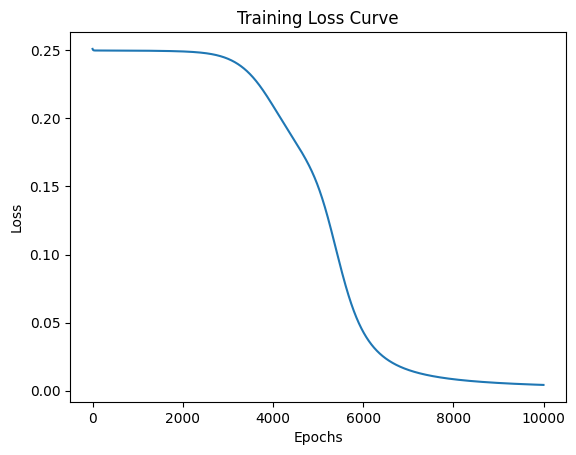

In [28]:
plt.plot(losses)
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training Loss Curve")
plt.show()


In [29]:
print("Predicted Output:")
print(np.round(y_hat, 3))


Predicted Output:
[[0.066]
 [0.938]
 [0.938]
 [0.067]]
